In [1]:
import pandas as pd
df = pd.read_csv('instagram_data.csv')
print(df.head())
print(df.columns)

         username  followers  following  posts  avg_likes  avg_comments  \
0   @real_user_73      47928      68328    156       1302           154   
1   @real_user_18     100859      82987    343       4243           535   
2  @real_user_118     475494     427335    573      45538          5440   
3   @real_user_78      47563      72630    418       2869           354   
4   @real_user_76      23030      12222    680       1938           173   

  category label  
0   Gaming  Real  
1   Beauty  Real  
2     Tech  Real  
3   Travel  Real  
4  Fitness  Real  
Index(['username', 'followers', 'following', 'posts', 'avg_likes',
       'avg_comments', 'category', 'label'],
      dtype='str')


In [2]:
df['engagement_rate'] = ((df['avg_likes'] + df['avg_comments']) / df['followers']) * 100
df['comment_like_ratio'] = df['avg_comments'] / (df['avg_likes'] + 1)
df['follower_following_ratio'] = df['followers'] / (df['following'] + 1)
print("Features created successfully")

Features created successfully


In [3]:
from sklearn.ensemble import IsolationForest

features = ['engagement_rate', 'comment_like_ratio', 'follower_following_ratio']
model = IsolationForest(contamination=0.2, random_state=42)
df['anomaly'] = model.fit_predict(df[features])
df['label'] = df['anomaly'].map({1: 'Real', -1: 'Fake'})
print(df['label'].value_counts())

label
Real    120
Fake     30
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


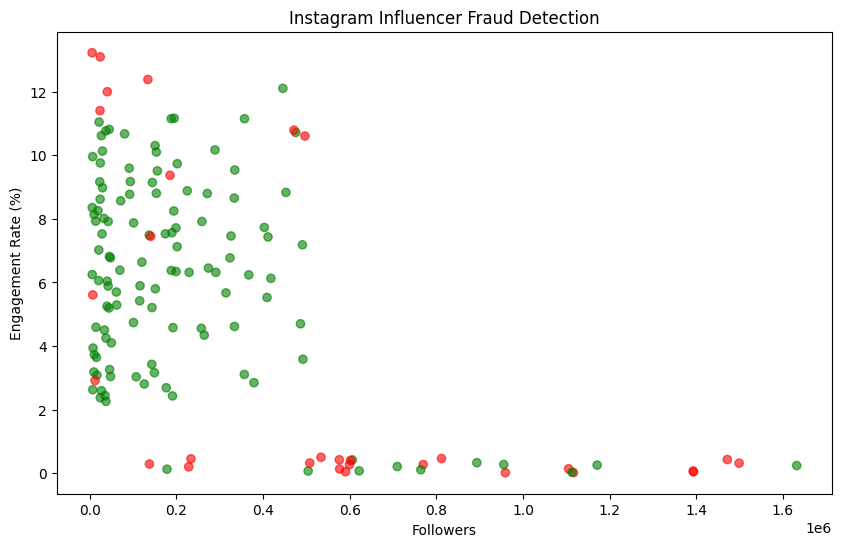

In [4]:
import matplotlib.pyplot as plt

colors = df['label'].map({'Real': 'green', 'Fake': 'red'})
plt.figure(figsize=(10, 6))
plt.scatter(df['followers'], df['engagement_rate'], c=colors, alpha=0.6)
plt.xlabel('Followers')
plt.ylabel('Engagement Rate (%)')
plt.title('Instagram Influencer Fraud Detection')
plt.savefig('fraud_chart.png')
plt.show()

In [5]:
fakes = df[df['label'] == 'Fake'][['username', 'followers', 'engagement_rate', 'avg_likes', 'avg_comments']]
fakes.to_csv('fake_accounts.csv', index=False)
print(f"Found {len(fakes)} fake accounts")
print(fakes.head(10))

Found 30 fake accounts
         username  followers  engagement_rate  avg_likes  avg_comments
6   @real_user_64       5404        13.230940        647            68
7   @fake_user_21    1105409         0.133887       1479             1
19  @fake_user_12     533816         0.496051       2636            12
20  @real_user_29      23589        11.407860       2350           341
21   @fake_user_7     769708         0.265945       2038             9
23   @fake_user_8     959297         0.010112         97             0
25  @fake_user_25     576840         0.127938        732             6
35  @fake_user_26     233541         0.445746       1032             9
36  @real_user_51     134076        12.388496      15736           874
40  @fake_user_22    1392964         0.064180        886             8


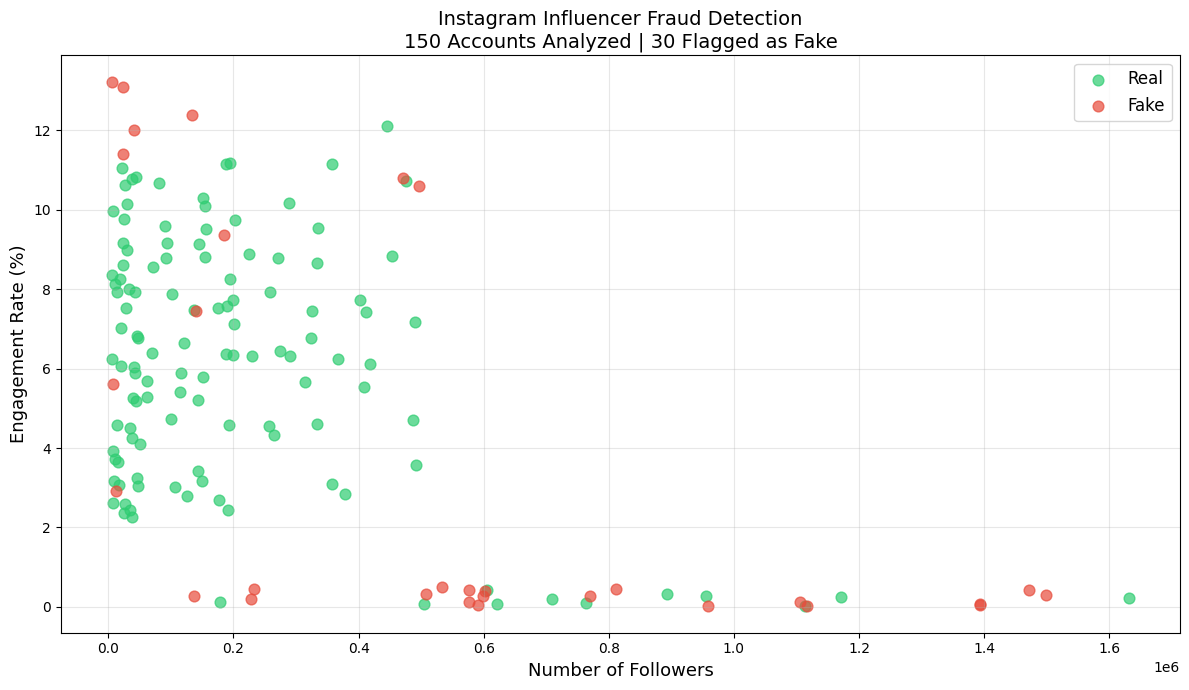

Chart saved!


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 7))

for label, color in [('Real', '#2ecc71'), ('Fake', '#e74c3c')]:
    subset = df[df['label'] == label]
    ax.scatter(subset['followers'], subset['engagement_rate'], 
               c=color, alpha=0.7, s=60, label=label)

ax.set_xlabel('Number of Followers', fontsize=13)
ax.set_ylabel('Engagement Rate (%)', fontsize=13)
ax.set_title('Instagram Influencer Fraud Detection\n150 Accounts Analyzed | 30 Flagged as Fake', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fraud_chart_final.png', dpi=150)
plt.show()
print("Chart saved!")